# 🍽️ What Factors Influence Restaurant Star Ratings on Yelp?
## Exploratory Data Analysis · Yelp Open Dataset

**Data Source:** Yelp Open Dataset (https://www.yelp.com/dataset)  
**Files Used:** `yelp_academic_dataset_business.json`, `yelp_academic_dataset_review.json`, `yelp_academic_dataset_checkin.json`

---
### Research Question
> **What factors influence a restaurant's star rating on Yelp?**

### Sub-Questions
| # | Question | Method |
|---|---|---|
| Q1 | Does **price tier** affect star ratings? | ANOVA + bar chart |
| Q2 | Does **review volume** correlate with ratings? | Pearson r + scatter |
| Q3 | Which **cuisine categories** rate highest/lowest? | Group means + bar |
| Q4 | Does **neighborhood/location** explain ratings? | Map + heatmap |
| Q5 | Do longer **operating hours** predict better ratings? | Correlation |
| Q6 | Do amenity **attributes** (parking, delivery, etc.) matter? | Mann-Whitney |
| Q7 | Does **review sentiment** align with star ratings? | TextBlob + correlation |

---
## Section 0 — Setup & Imports

In [1]:
# Install required packages (run once)
# !pip install textblob pandas numpy matplotlib seaborn scipy scikit-learn tqdm

import json
import os
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from textblob import TextBlob
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['text.usetex'] = False

print('✅ All libraries loaded.')

✅ All libraries loaded.


---
## Section 1 — Data Loading

⚠️ **Update `DATA_DIR` to point to your local Yelp dataset folder.**

In [2]:
# ── CONFIGURE THIS ────────────────────────────────────────────────────────────
DATA_DIR = Path('C:\\Users\\PC\\OneDrive\\Desktop\\Data Bootcamp\\data')   # <-- change to your folder path
# e.g. Path('/Users/yourname/Downloads/yelp_dataset')
# ─────────────────────────────────────────────────────────────────────────────

BUSINESS_FILE = DATA_DIR / 'yelp_academic_dataset_business.json'
REVIEW_FILE   = DATA_DIR / 'yelp_academic_dataset_review.json'
CHECKIN_FILE  = DATA_DIR / 'yelp_academic_dataset_checkin.json'

def load_json_lines(filepath, max_rows=None):
    """Load a JSON-lines file into a DataFrame."""
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_rows and i >= max_rows:
                break
            records.append(json.loads(line))
    return pd.DataFrame(records)

print('Loading business data...')
df_biz_raw = load_json_lines(BUSINESS_FILE)
print(f'  Business records: {len(df_biz_raw):,}')

print('Loading checkin data...')
df_checkin_raw = load_json_lines(CHECKIN_FILE)
print(f'  Checkin records:  {len(df_checkin_raw):,}')

# Reviews are large — load a sample for sentiment analysis
print('Loading review data (first 200,000 rows)...')
df_review_raw = load_json_lines(REVIEW_FILE, max_rows=200_000)
print(f'  Review records:   {len(df_review_raw):,}')

print('\n✅ Data loaded.')

Loading business data...
  Business records: 150,346
Loading checkin data...
  Checkin records:  131,930
Loading review data (first 200,000 rows)...
  Review records:   200,000

✅ Data loaded.


---
## Section 2 — Data Cleaning & Feature Engineering

In [3]:
# ── Filter to restaurants only ────────────────────────────────────────────────
def is_restaurant(categories):
    # Categories field is a comma-separated string in the Yelp dataset
    if not isinstance(categories, str) or not categories:
        return False
    cats = [c.strip().lower() for c in categories.split(',')]
    restaurant_terms = {'restaurants', 'food', 'bars', 'nightlife',
                        'fast food', 'cafes', 'desserts', 'bakeries'}
    return bool(restaurant_terms & set(cats))

df_rest = df_biz_raw[df_biz_raw['categories'].apply(is_restaurant)].copy()
print(f'Restaurants: {len(df_rest):,} (out of {len(df_biz_raw):,} total businesses)')

# ── Price tier ────────────────────────────────────────────────────────────────
def extract_price(attributes):
    if isinstance(attributes, dict):
        return attributes.get('RestaurantsPriceRange2', None)
    return None

df_rest['price_raw'] = df_rest['attributes'].apply(extract_price)
df_rest['price_num'] = pd.to_numeric(df_rest['price_raw'], errors='coerce')
df_rest['price_label'] = df_rest['price_num'].map({1:'$', 2:'$$', 3:'$$$', 4:'$$$$'})

# ── Hours: total weekly operating hours ───────────────────────────────────────
def calc_weekly_hours(hours_dict):
    if not isinstance(hours_dict, dict):
        return np.nan
    total = 0
    for _, span in hours_dict.items():
        try:
            start, end = span.split('-')
            sh, sm = map(int, start.split(':'))
            eh, em = map(int, end.split(':'))
            mins = (eh * 60 + em) - (sh * 60 + sm)
            if mins < 0: mins += 24 * 60  # overnight
            total += mins / 60
        except:
            pass
    return total if total > 0 else np.nan

df_rest['weekly_hours'] = df_rest['hours'].apply(calc_weekly_hours)

# ── Attribute flags ───────────────────────────────────────────────────────────
def get_attr(attributes, key):
    if isinstance(attributes, dict):
        val = attributes.get(key, None)
        if isinstance(val, bool): return int(val)
        if isinstance(val, str):
            if val.lower() in ('true', '1'): return 1
            if val.lower() in ('false', '0'): return 0
    return np.nan

attr_flags = {
    'has_takeout':    ('RestaurantsTakeOut',),
    'has_delivery':   ('RestaurantsDelivery',),
    'has_reservation':('RestaurantsReservations',),
    'has_wifi':       ('WiFi',),
    'good_for_kids':  ('GoodForKids',),
    'outdoor_seating':('OutdoorSeating',),
}
for col, (key,) in attr_flags.items():
    df_rest[col] = df_rest['attributes'].apply(lambda a: get_attr(a, key))

# Parking (nested object)
def has_parking(attributes):
    if isinstance(attributes, dict):
        p = attributes.get('BusinessParking', {})
        if isinstance(p, dict):
            return int(any(p.values()))
        if isinstance(p, str) and 'true' in p.lower():
            return 1
    return np.nan

df_rest['has_parking'] = df_rest['attributes'].apply(has_parking)

# ── Primary cuisine category ──────────────────────────────────────────────────
EXCLUDE = {'restaurants', 'food', 'bars', 'nightlife', 'event planning & services',
           'arts & entertainment', 'shopping', 'active life'}

def primary_cuisine(cats):
    if not isinstance(cats, str) or not cats:
        return 'Other'
    for c in cats.split(','):
        c = c.strip()
        if c.lower() not in EXCLUDE:
            return c
    return 'Other'

df_rest['cuisine'] = df_rest['categories'].apply(primary_cuisine)

# ── Checkin count per business ────────────────────────────────────────────────
def count_checkins(date_str):
    if not isinstance(date_str, str):
        return 0
    return len(date_str.split(','))

df_checkin_raw['checkin_count'] = df_checkin_raw['date'].apply(count_checkins)
checkin_map = df_checkin_raw.set_index('business_id')['checkin_count'].to_dict()
df_rest['checkin_count'] = df_rest['business_id'].map(checkin_map).fillna(0).astype(int)

# ── Final clean columns ───────────────────────────────────────────────────────
df = df_rest[[
    'business_id', 'name', 'city', 'state', 'latitude', 'longitude',
    'stars', 'review_count', 'is_open',
    'price_num', 'price_label',
    'weekly_hours', 'cuisine',
    'has_takeout', 'has_delivery', 'has_reservation',
    'has_wifi', 'good_for_kids', 'outdoor_seating', 'has_parking',
    'checkin_count'
]].copy()

df['log_review_count'] = np.log1p(df['review_count'])
df['log_checkin_count'] = np.log1p(df['checkin_count'])

print(f'\nFinal dataset shape: {df.shape}')
print(f'Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())
df.head(3)

Restaurants: 67,533 (out of 150,346 total businesses)

Final dataset shape: (67533, 23)
Missing values:
price_num          10553
price_label        10553
weekly_hours       12270
has_takeout        11032
has_delivery       16603
has_reservation    22822
has_wifi           67533
good_for_kids      24816
outdoor_seating    20889
has_parking        17145


,business_id,name,city,state,latitude,longitude,stars,review_count,is_open,price_num,...,has_takeout,has_delivery,has_reservation,has_wifi,good_for_kids,outdoor_seating,has_parking,checkin_count,log_review_count,log_checkin_count
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,39.955505,-75.155564,4.0,80,1,1.0,...,1.0,0.0,NaN,NaN,NaN,0.0,1.0,335,4.394449,5.817111
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,Green Lane,PA,40.338183,-75.471659,4.5,13,1,NaN,...,1.0,NaN,NaN,NaN,1.0,NaN,1.0,14,2.639057,2.708050
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,TN,36.269593,-87.058943,2.0,6,1,1.0,...,1.0,1.0,0.0,NaN,1.0,1.0,NaN,22,1.945910,3.135494


---
## Section 3 — Descriptive Statistics & Target Distribution

In [4]:
print('=== Descriptive Statistics ===')
display(df[['stars', 'review_count', 'weekly_hours', 'checkin_count']].describe().round(2))

=== Descriptive Statistics ===


,stars,review_count,weekly_hours,checkin_count
count,67533.00,67533.00,55263.00,67533.00
mean,3.55,75.14,67.25,153.81
std,0.85,171.05,25.83,432.50
min,1.00,5.00,0.25,0.00
25%,3.00,11.00,49.50,12.00
50%,3.50,27.00,68.00,42.00
75%,4.00,74.00,83.00,138.00
max,5.00,7568.00,167.88,40109.00


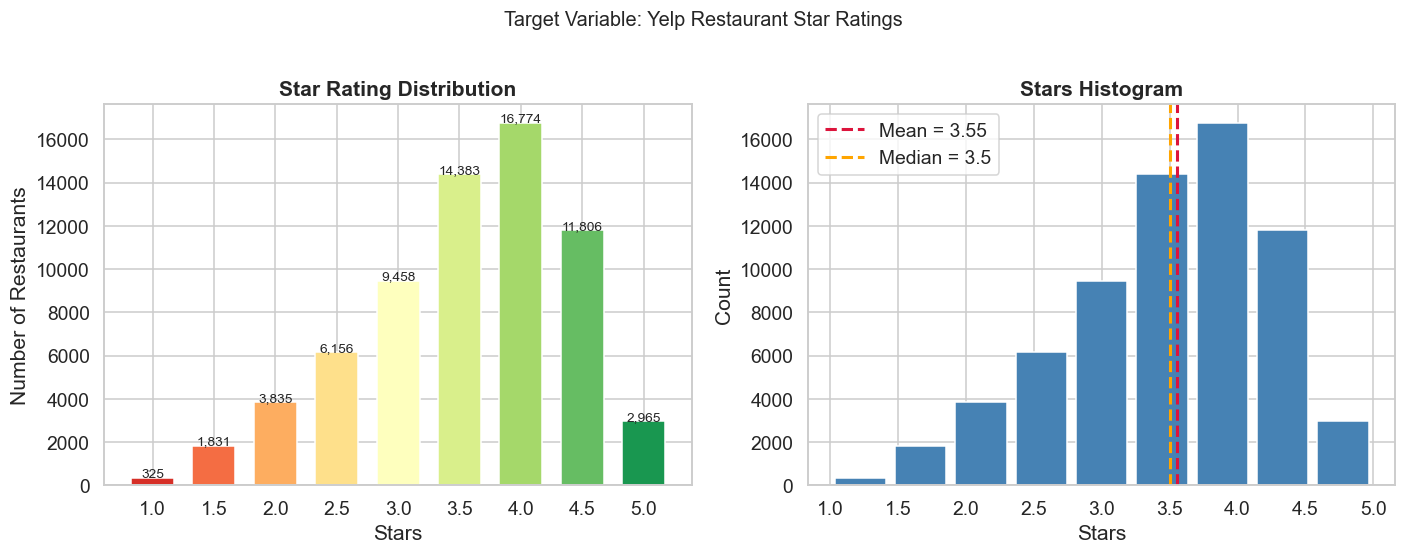

In [5]:
# ── Star rating distribution ──────────────────────────────────────────────────
star_counts = df['stars'].value_counts().sort_index()
STAR_COLORS = sns.color_palette('RdYlGn', len(star_counts))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(star_counts.index.astype(str), star_counts.values,
            color=STAR_COLORS, edgecolor='white', width=0.7)
axes[0].set_title('Star Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Number of Restaurants')
for i, (x, y) in enumerate(zip(star_counts.index, star_counts.values)):
    axes[0].text(i, y + 50, f'{y:,}', ha='center', fontsize=9)

axes[1].hist(df['stars'], bins=9, color='steelblue', edgecolor='white', rwidth=0.85)
axes[1].axvline(df['stars'].mean(), color='crimson', linestyle='--',
                linewidth=2, label=f'Mean = {df["stars"].mean():.2f}')
axes[1].axvline(df['stars'].median(), color='orange', linestyle='--',
                linewidth=2, label=f'Median = {df["stars"].median():.1f}')
axes[1].set_title('Stars Histogram', fontweight='bold')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Target Variable: Yelp Restaurant Star Ratings', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_star_distribution.png', bbox_inches='tight')
plt.show()

---
## Section 4 — Q1: Price Tier vs. Star Rating

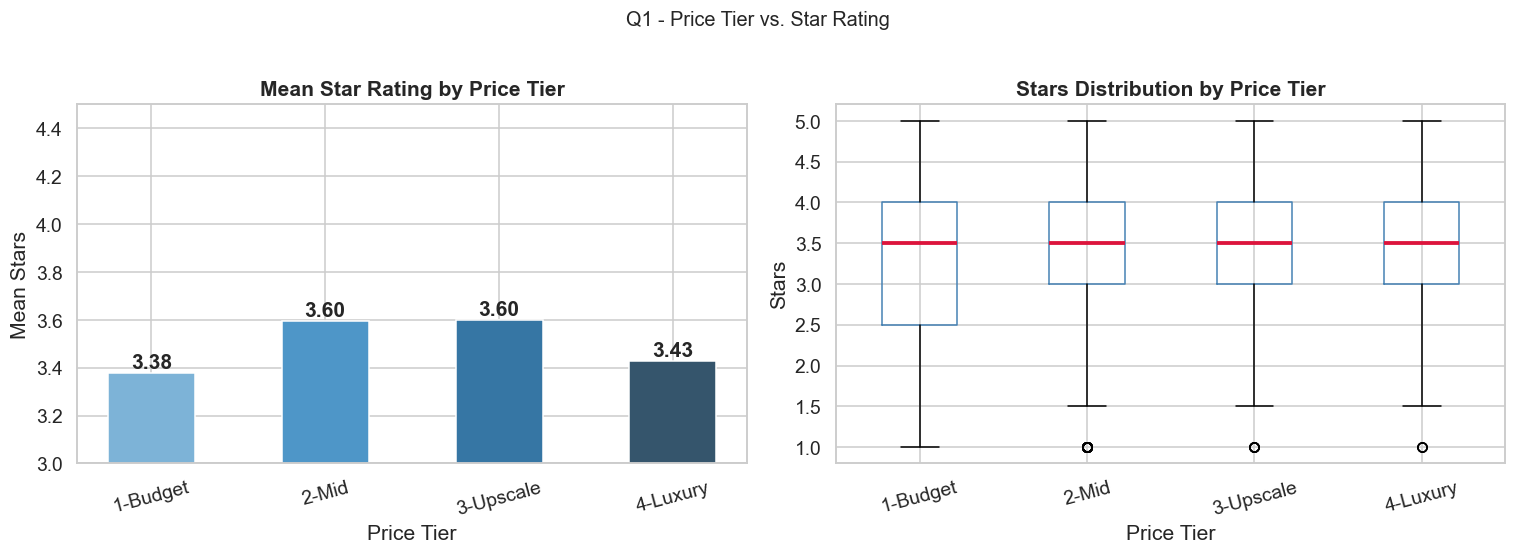

One-way ANOVA (Price vs Stars): F = 330.79,  p = 0.0000

Price tier summary:
                 mean  median  count
price_label                         
$            3.376461     3.5  24551
$$           3.595214     3.5  29817
$$$          3.597788     3.5   2306
$$$$         3.426471     3.5    306


In [8]:
price_df = df.dropna(subset=['price_label'])
PRICE_ORDER  = ['$', '$$', '$$$', '$$$$']
PRICE_LABELS = ['1-Budget', '2-Mid', '3-Upscale', '4-Luxury']  # no $ symbols at all
price_map    = dict(zip(PRICE_ORDER, PRICE_LABELS))
price_df2    = price_df.copy()
price_df2['price_display'] = price_df2['price_label'].map(price_map)
price_stats  = price_df.groupby('price_label')['stars'].agg(['mean','median','count']).reindex(PRICE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('Blues_d', 4)
bars = axes[0].bar(PRICE_LABELS, price_stats['mean'], color=colors, edgecolor='white', width=0.5)
axes[0].set_ylim(3.0, 4.5)
axes[0].set_title('Mean Star Rating by Price Tier', fontweight='bold')
axes[0].set_xlabel('Price Tier')
axes[0].set_ylabel('Mean Stars')
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, price_stats['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.2f}', ha='center', fontweight='bold')

bp_data   = [price_df2[price_df2['price_display']==p]['stars'].dropna() for p in PRICE_LABELS]
bp_data   = [d for d in bp_data if len(d) > 0]
bp_labels = [p for p, d in zip(PRICE_LABELS,
              [price_df2[price_df2['price_display']==p]['stars'].dropna()
               for p in PRICE_LABELS]) if len(d) > 0]
axes[1].boxplot(bp_data, labels=bp_labels,
    boxprops=dict(color='steelblue'), medianprops=dict(color='crimson', linewidth=2.5))
axes[1].set_title('Stars Distribution by Price Tier', fontweight='bold')
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Stars')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Q1 - Price Tier vs. Star Rating', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig2_price_vs_stars.png', bbox_inches='tight')
plt.show()

groups = [price_df[price_df['price_label']==p]['stars'].dropna() for p in PRICE_ORDER]
f, p_val = stats.f_oneway(*[g for g in groups if len(g) > 0])
print(f'One-way ANOVA (Price vs Stars): F = {f:.2f},  p = {p_val:.4f}')
print('\nPrice tier summary:')
print(price_stats.to_string())


---
## Section 5 — Q2: Review Count vs. Star Rating

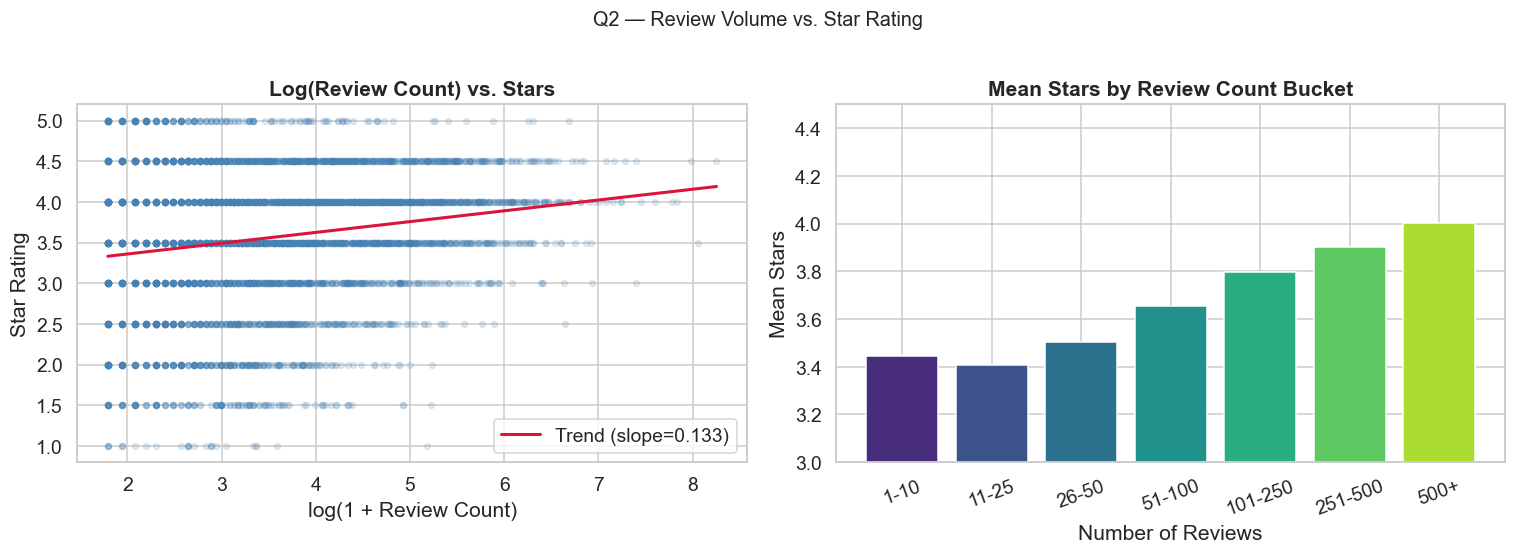

Pearson r (log_review_count vs stars): r = +0.180,  p = 0.0000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: log review count vs stars
sample = df.dropna(subset=['stars', 'review_count']).sample(min(5000, len(df)), random_state=42)
axes[0].scatter(sample['log_review_count'], sample['stars'],
                alpha=0.15, s=15, color='steelblue')
# Trend line
m, b = np.polyfit(sample['log_review_count'], sample['stars'], 1)
x_line = np.linspace(sample['log_review_count'].min(), sample['log_review_count'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='crimson', linewidth=2, label=f'Trend (slope={m:.3f})')
axes[0].set_title('Log(Review Count) vs. Stars', fontweight='bold')
axes[0].set_xlabel('log(1 + Review Count)')
axes[0].set_ylabel('Star Rating')
axes[0].legend()

# Mean stars by review count bin
df['review_bin'] = pd.cut(df['review_count'],
    bins=[0, 10, 25, 50, 100, 250, 500, 10000],
    labels=['1-10','11-25','26-50','51-100','101-250','251-500','500+'])
rev_stars = df.groupby('review_bin', observed=True)['stars'].mean()
axes[1].bar(rev_stars.index.astype(str), rev_stars.values,
            color=sns.color_palette('viridis', len(rev_stars)), edgecolor='white')
axes[1].set_title('Mean Stars by Review Count Bucket', fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Mean Stars')
axes[1].set_ylim(3.0, 4.5)
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Q2 — Review Volume vs. Star Rating', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_reviews_vs_stars.png', bbox_inches='tight')
plt.show()

# Pearson correlation
tmp = df[['log_review_count', 'stars']].dropna()
r, p_r = stats.pearsonr(tmp['log_review_count'], tmp['stars'])
print(f'Pearson r (log_review_count vs stars): r = {r:+.3f},  p = {p_r:.4f}')

---
## Section 6 — Q3: Cuisine Category vs. Star Rating

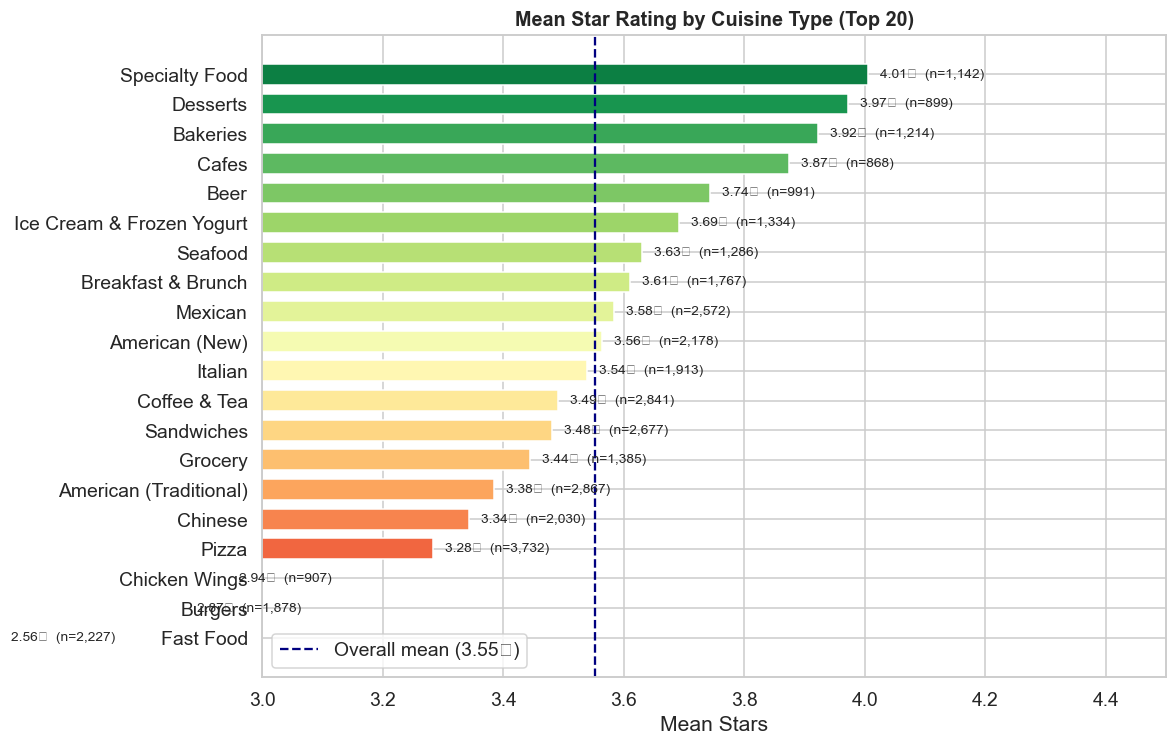

In [10]:
# Top 20 most common cuisines with >= 30 restaurants
cuisine_counts = df['cuisine'].value_counts()
top_cuisines = cuisine_counts[cuisine_counts >= 30].head(20).index.tolist()

cuisine_stats = (
    df[df['cuisine'].isin(top_cuisines)]
    .groupby('cuisine')['stars']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
colors = sns.color_palette('RdYlGn', len(cuisine_stats))
bars = ax.barh(cuisine_stats.index, cuisine_stats['mean'],
               color=colors, edgecolor='white', height=0.7)
ax.axvline(df['stars'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f'Overall mean ({df["stars"].mean():.2f}★)')
ax.set_title('Mean Star Rating by Cuisine Type (Top 20)', fontweight='bold', fontsize=13)
ax.set_xlabel('Mean Stars')
ax.set_xlim(3.0, 4.5)
ax.legend()
for bar, (mean_val, count) in zip(bars, cuisine_stats[['mean','count']].values):
    ax.text(mean_val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{mean_val:.2f}★  (n={int(count):,})', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig4_cuisine_vs_stars.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Q4: Geography / City vs. Star Rating

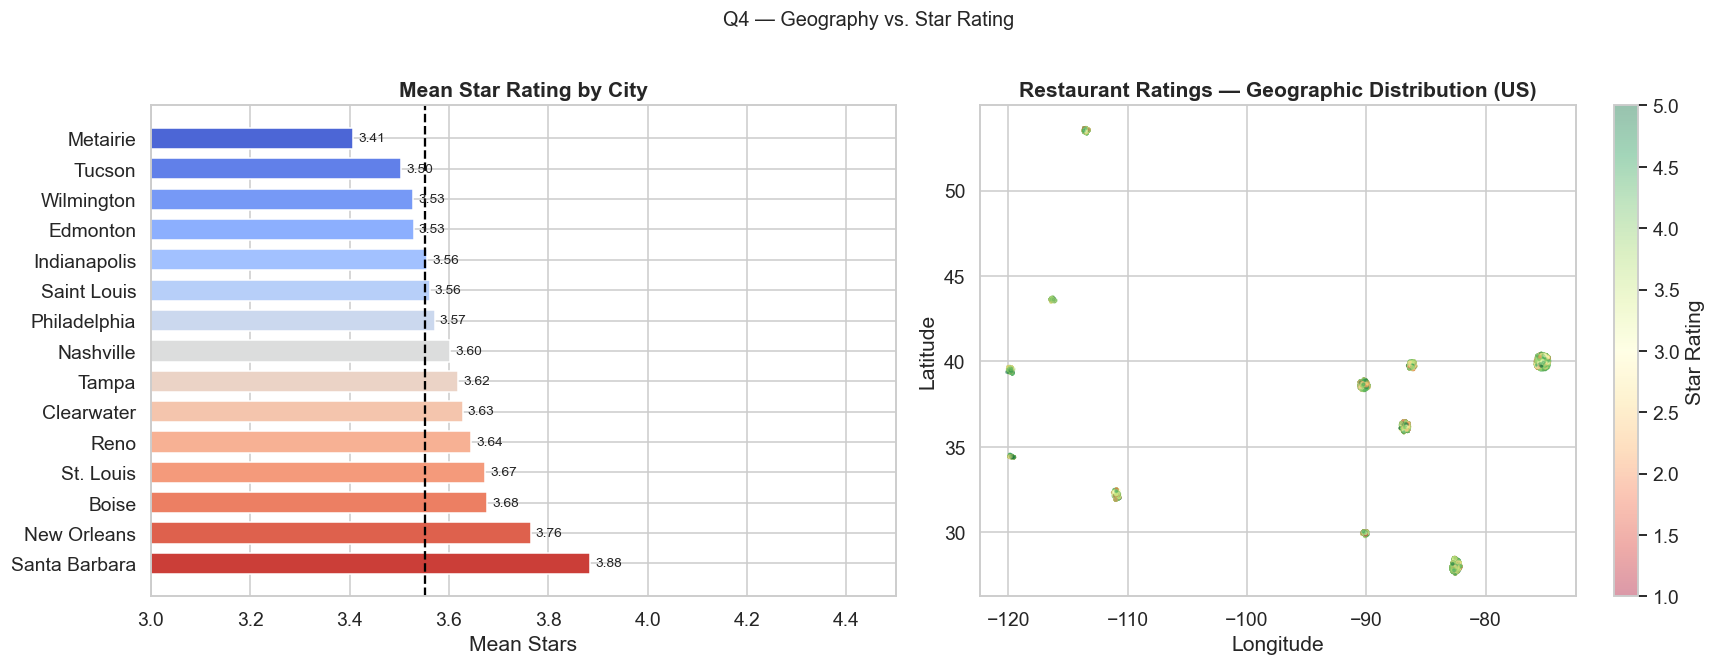

One-way ANOVA (City → Stars): F = 29.12,  p = 0.0000


In [11]:
# Top 15 cities by restaurant count
city_counts = df['city'].value_counts()
top_cities = city_counts[city_counts >= 50].head(15).index.tolist()

city_stats = (
    df[df['city'].isin(top_cities)]
    .groupby('city')['stars']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart by city
colors = sns.color_palette('coolwarm_r', len(city_stats))
bars = axes[0].barh(city_stats.index, city_stats['mean'],
                    color=colors, edgecolor='white', height=0.7)
axes[0].axvline(df['stars'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Mean Star Rating by City', fontweight='bold')
axes[0].set_xlabel('Mean Stars')
axes[0].set_xlim(3.0, 4.5)
for bar, v in zip(bars, city_stats['mean'].values):
    axes[0].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}', va='center', fontsize=9)

# Scatter: lat/lon colored by stars
geo_df = df.dropna(subset=['latitude', 'longitude', 'stars'])
geo_df = geo_df[(geo_df['latitude'].between(20, 55)) &
                (geo_df['longitude'].between(-130, -60))]
sc = axes[1].scatter(geo_df['longitude'], geo_df['latitude'],
                     c=geo_df['stars'], cmap='RdYlGn',
                     s=3, alpha=0.4, vmin=1, vmax=5)
plt.colorbar(sc, ax=axes[1], label='Star Rating')
axes[1].set_title('Restaurant Ratings — Geographic Distribution (US)', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Q4 — Geography vs. Star Rating', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig5_geography_vs_stars.png', bbox_inches='tight')
plt.show()

# ANOVA: city effect on stars
city_groups = [df[df['city']==c]['stars'].dropna() for c in top_cities]
f_city, p_city = stats.f_oneway(*[g for g in city_groups if len(g)>1])
print(f'One-way ANOVA (City → Stars): F = {f_city:.2f},  p = {p_city:.4f}')

---
## Section 8 — Q5: Operating Hours vs. Star Rating

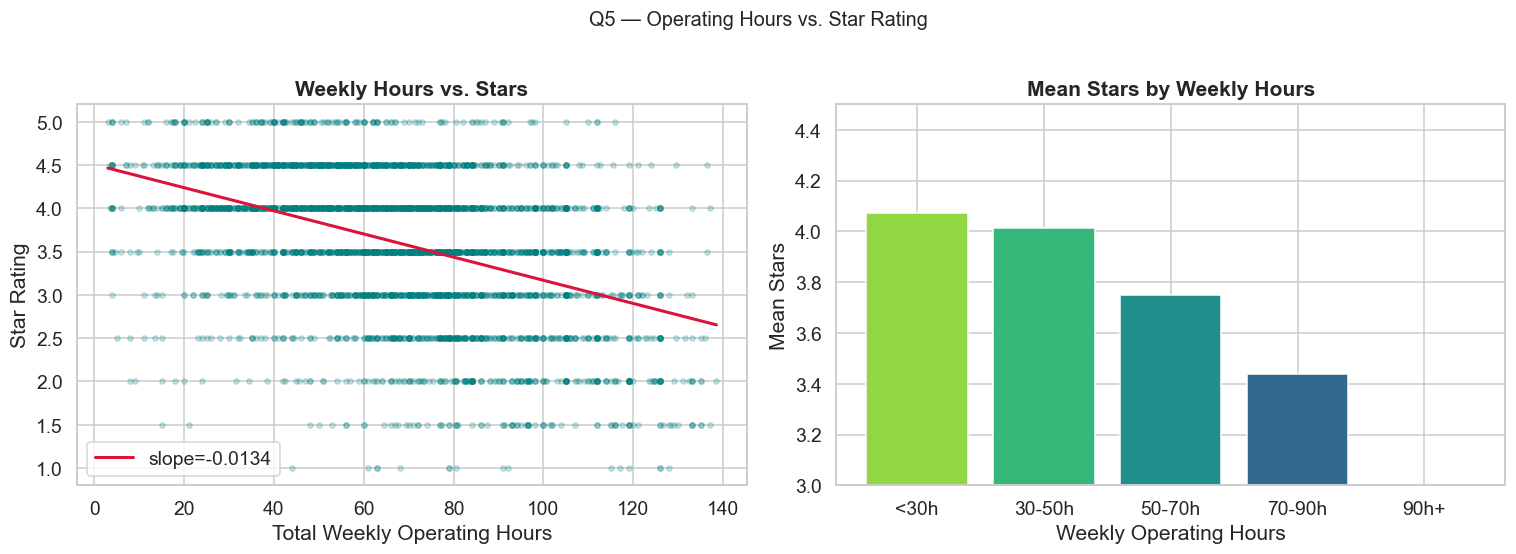

Pearson r (weekly_hours vs stars): r = -0.443,  p = 0.0000


In [12]:
hours_df = df.dropna(subset=['weekly_hours', 'stars'])
hours_df = hours_df[hours_df['weekly_hours'].between(1, 140)]  # remove outliers

# Bin weekly hours
hours_df['hours_bin'] = pd.cut(hours_df['weekly_hours'],
    bins=[0, 30, 50, 70, 90, 140],
    labels=['<30h', '30-50h', '50-70h', '70-90h', '90h+'])

hours_stats = hours_df.groupby('hours_bin', observed=True)['stars'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
sample_h = hours_df.sample(min(4000, len(hours_df)), random_state=42)
axes[0].scatter(sample_h['weekly_hours'], sample_h['stars'],
                alpha=0.2, s=12, color='teal')
m, b = np.polyfit(sample_h['weekly_hours'], sample_h['stars'], 1)
x_l = np.linspace(sample_h['weekly_hours'].min(), sample_h['weekly_hours'].max(), 100)
axes[0].plot(x_l, m*x_l+b, color='crimson', linewidth=2, label=f'slope={m:.4f}')
axes[0].set_title('Weekly Hours vs. Stars', fontweight='bold')
axes[0].set_xlabel('Total Weekly Operating Hours')
axes[0].set_ylabel('Star Rating')
axes[0].legend()

# Bar by bin
axes[1].bar(hours_stats.index.astype(str), hours_stats.values,
            color=sns.color_palette('viridis_r', 5), edgecolor='white')
axes[1].set_title('Mean Stars by Weekly Hours', fontweight='bold')
axes[1].set_xlabel('Weekly Operating Hours')
axes[1].set_ylabel('Mean Stars')
axes[1].set_ylim(3.0, 4.5)

plt.suptitle('Q5 — Operating Hours vs. Star Rating', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig6_hours_vs_stars.png', bbox_inches='tight')
plt.show()

r_h, p_h = stats.pearsonr(hours_df['weekly_hours'], hours_df['stars'])
print(f'Pearson r (weekly_hours vs stars): r = {r_h:+.3f},  p = {p_h:.4f}')

---
## Section 9 — Q6: Amenity Attributes vs. Star Rating

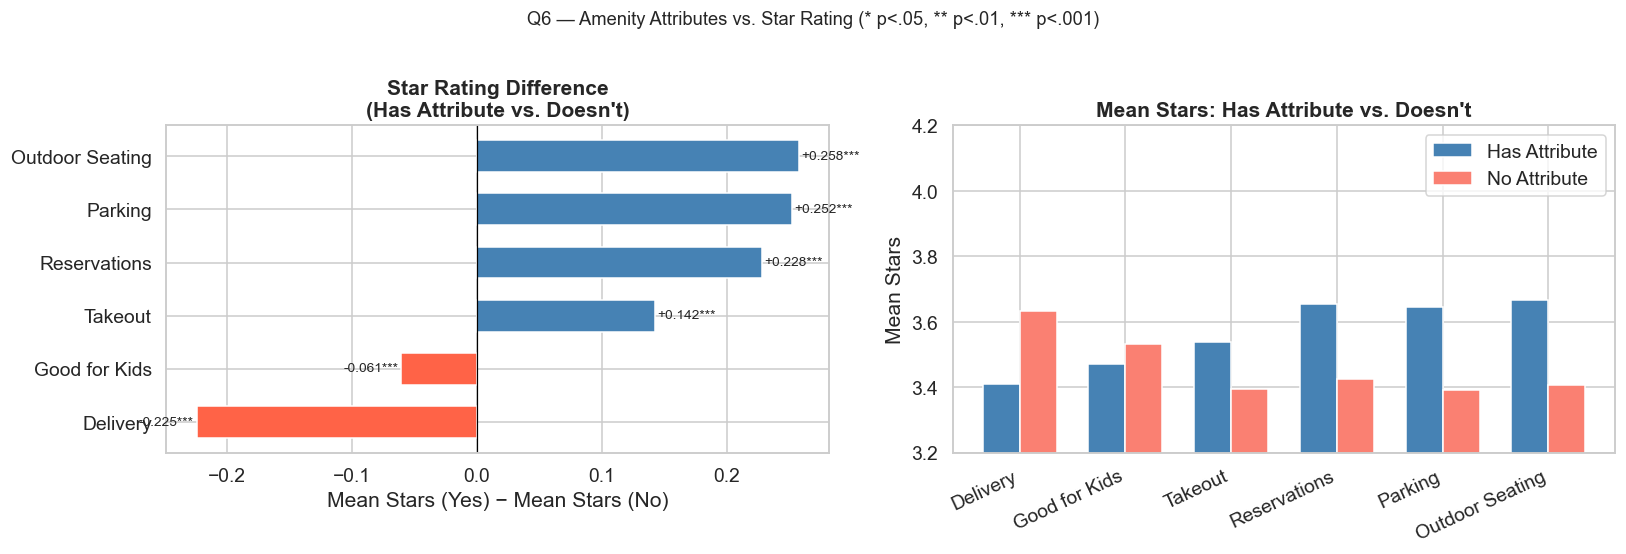

      Attribute  Mean (Yes)  Mean (No)      Diff       p-value
       Delivery    3.409672   3.634254 -0.224582 2.364044e-139
  Good for Kids    3.470402   3.531503 -0.061102  1.454568e-08
        Takeout    3.537597   3.395246  0.142351  9.979146e-14
   Reservations    3.653862   3.425781  0.228081 2.098940e-119
        Parking    3.644354   3.392093  0.252260  1.534550e-61
Outdoor Seating    3.665121   3.407361  0.257760 4.807967e-238


In [13]:
ATTRS = {
    'has_takeout':     'Takeout',
    'has_delivery':    'Delivery',
    'has_reservation': 'Reservations',
    'has_wifi':        'Wi-Fi',
    'good_for_kids':   'Good for Kids',
    'outdoor_seating': 'Outdoor Seating',
    'has_parking':     'Parking',
}

results = []
for col, label in ATTRS.items():
    sub = df.dropna(subset=[col, 'stars'])
    sub = sub[sub[col].isin([0, 1])]
    yes = sub[sub[col]==1]['stars']
    no  = sub[sub[col]==0]['stars']
    if len(yes) > 10 and len(no) > 10:
        u, p = stats.mannwhitneyu(yes, no, alternative='two-sided')
        results.append({
            'Attribute': label,
            'Mean (Yes)': yes.mean(),
            'Mean (No)':  no.mean(),
            'Diff': yes.mean() - no.mean(),
            'n (Yes)': len(yes),
            'n (No)': len(no),
            'p-value': p
        })

attr_results = pd.DataFrame(results).sort_values('Diff', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Diff bar chart
colors = ['tomato' if d < 0 else 'steelblue' for d in attr_results['Diff']]
axes[0].barh(attr_results['Attribute'], attr_results['Diff'],
             color=colors, edgecolor='white', height=0.6)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Star Rating Difference\n(Has Attribute vs. Doesn\'t)', fontweight='bold')
axes[0].set_xlabel('Mean Stars (Yes) − Mean Stars (No)')
for i, (v, p) in enumerate(zip(attr_results['Diff'], attr_results['p-value'])):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    axes[0].text(v + (0.002 if v >= 0 else -0.002), i, f'{v:+.3f}{sig}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Grouped bar: Yes vs No
x = np.arange(len(attr_results))
w = 0.35
axes[1].bar(x - w/2, attr_results['Mean (Yes)'], w, label='Has Attribute',
            color='steelblue', edgecolor='white')
axes[1].bar(x + w/2, attr_results['Mean (No)'], w, label='No Attribute',
            color='salmon', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(attr_results['Attribute'], rotation=25, ha='right')
axes[1].set_ylim(3.2, 4.2)
axes[1].set_title('Mean Stars: Has Attribute vs. Doesn\'t', fontweight='bold')
axes[1].set_ylabel('Mean Stars')
axes[1].legend()

plt.suptitle('Q6 — Amenity Attributes vs. Star Rating (* p<.05, ** p<.01, *** p<.001)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig7_attributes_vs_stars.png', bbox_inches='tight')
plt.show()

print(attr_results[['Attribute','Mean (Yes)','Mean (No)','Diff','p-value']].to_string(index=False))

---
## Section 10 — Q7: Review Sentiment vs. Star Rating

Using **TextBlob** to compute sentiment polarity (−1 = very negative → +1 = very positive) for each review, then comparing to the star rating given.

In [14]:
# ── Compute sentiment for review sample ──────────────────────────────────────
print('Computing sentiment scores (this takes ~1-2 minutes)...')

# Filter to restaurant reviews only
rest_ids = set(df['business_id'])
rev_rest = df_review_raw[df_review_raw['business_id'].isin(rest_ids)].copy()

# Sample if large
if len(rev_rest) > 50_000:
    rev_rest = rev_rest.sample(50_000, random_state=42)

def get_sentiment(text):
    if not isinstance(text, str) or len(text) < 5:
        return np.nan
    return TextBlob(text).sentiment.polarity

tqdm.pandas(desc='Sentiment')
rev_rest['sentiment'] = rev_rest['text'].progress_apply(get_sentiment)

print(f'\nSentiment computed for {len(rev_rest):,} reviews')
print(rev_rest[['stars', 'sentiment']].describe().round(3))

Computing sentiment scores (this takes ~1-2 minutes)...


Sentiment: 100%|██████████| 50000/50000 [01:18<00:00, 638.82it/s] 



Sentiment computed for 50,000 reviews
           stars  sentiment
count  50000.000  49999.000
mean       3.837      0.267
std        1.320      0.229
min        1.000     -1.000
25%        3.000      0.135
50%        4.000      0.269
75%        5.000      0.404
max        5.000      1.000


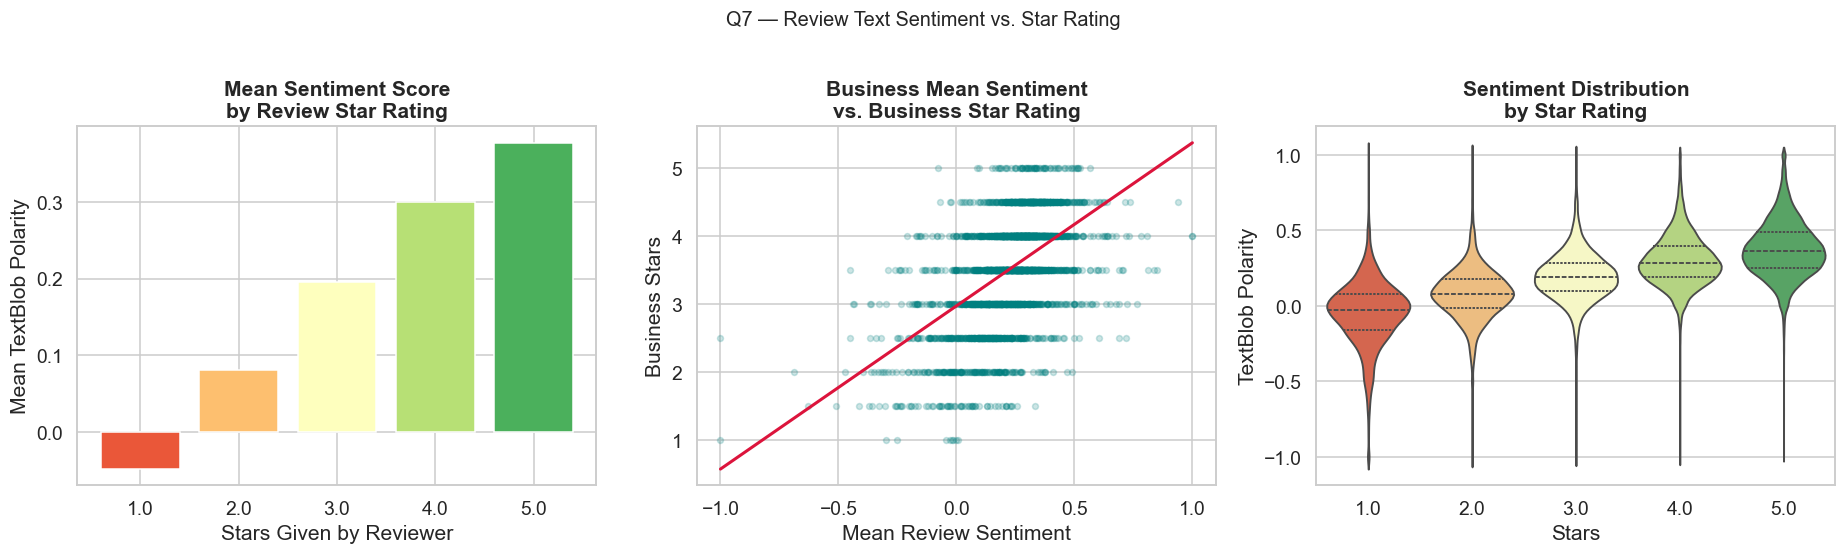

Pearson r (review sentiment vs review stars): r = +0.597,  p = 0.00e+00


In [15]:
# ── Aggregate sentiment per business → merge with main df ─────────────────────
biz_sentiment = rev_rest.groupby('business_id')['sentiment'].agg(['mean','std','count'])
biz_sentiment.columns = ['mean_sentiment', 'std_sentiment', 'sentiment_review_count']
df_sent = df.merge(biz_sentiment, on='business_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1) Mean sentiment by star tier
sent_by_star = rev_rest.groupby('stars')['sentiment'].mean().reset_index()
axes[0].bar(sent_by_star['stars'].astype(str), sent_by_star['sentiment'],
            color=sns.color_palette('RdYlGn', len(sent_by_star)), edgecolor='white')
axes[0].set_title('Mean Sentiment Score\nby Review Star Rating', fontweight='bold')
axes[0].set_xlabel('Stars Given by Reviewer')
axes[0].set_ylabel('Mean TextBlob Polarity')

# 2) Scatter: biz mean sentiment vs biz stars
sent_sample = df_sent.dropna(subset=['mean_sentiment', 'stars']).sample(
    min(3000, len(df_sent.dropna(subset=['mean_sentiment','stars']))), random_state=42)
axes[1].scatter(sent_sample['mean_sentiment'], sent_sample['stars'],
                alpha=0.2, s=15, color='teal')
m2, b2 = np.polyfit(sent_sample['mean_sentiment'], sent_sample['stars'], 1)
xl = np.linspace(sent_sample['mean_sentiment'].min(), sent_sample['mean_sentiment'].max(), 100)
axes[1].plot(xl, m2*xl+b2, color='crimson', linewidth=2)
axes[1].set_title('Business Mean Sentiment\nvs. Business Star Rating', fontweight='bold')
axes[1].set_xlabel('Mean Review Sentiment')
axes[1].set_ylabel('Business Stars')

# 3) Violin: sentiment distribution by star tier
rev_plot = rev_rest.dropna(subset=['sentiment'])
rev_plot = rev_plot[rev_plot['stars'].isin([1,2,3,4,5])]
sns.violinplot(data=rev_plot, x='stars', y='sentiment',
               palette='RdYlGn', inner='quartile', ax=axes[2])
axes[2].set_title('Sentiment Distribution\nby Star Rating', fontweight='bold')
axes[2].set_xlabel('Stars')
axes[2].set_ylabel('TextBlob Polarity')

plt.suptitle('Q7 — Review Text Sentiment vs. Star Rating', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig8_sentiment_vs_stars.png', bbox_inches='tight')
plt.show()

# Correlation
tmp_s = rev_rest[['sentiment', 'stars']].dropna()
r_s, p_s = stats.pearsonr(tmp_s['sentiment'], tmp_s['stars'])
print(f'Pearson r (review sentiment vs review stars): r = {r_s:+.3f},  p = {p_s:.2e}')

---
## Section 11 — Multivariate Analysis: Correlation Heatmap & Regression

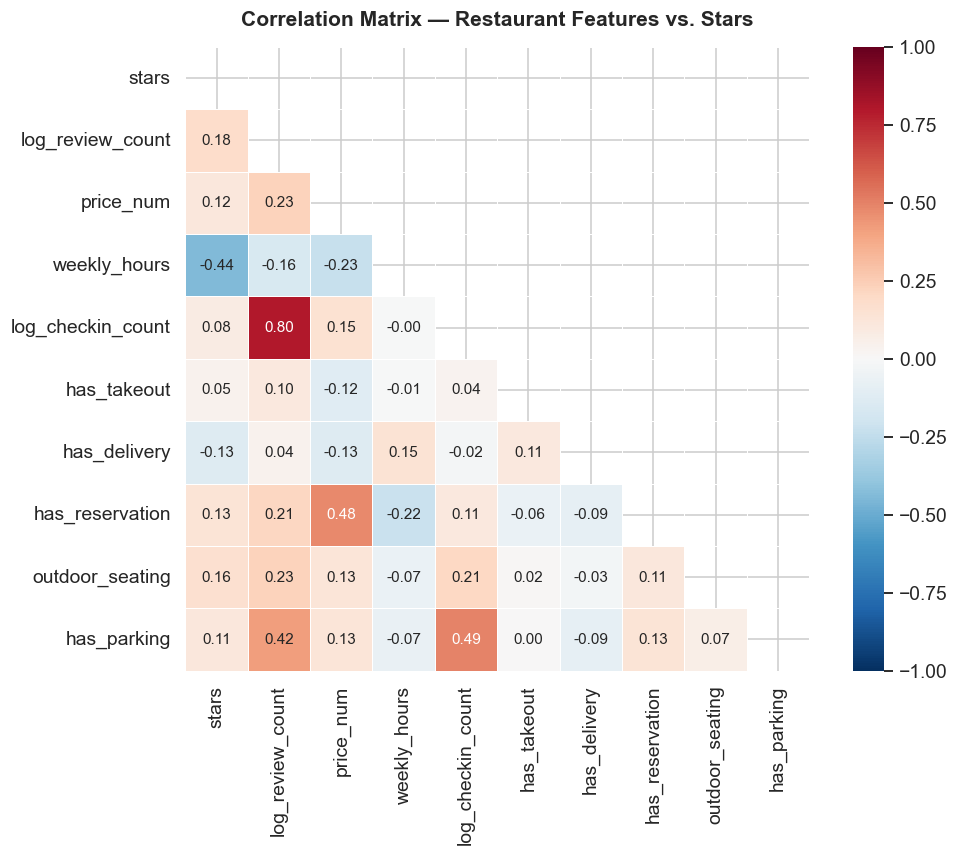

In [16]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
num_cols = ['stars', 'log_review_count', 'price_num', 'weekly_hours',
            'log_checkin_count', 'has_takeout', 'has_delivery',
            'has_reservation', 'outdoor_seating', 'has_parking']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Matrix — Restaurant Features vs. Stars',
             fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('fig9_correlation_heatmap.png', bbox_inches='tight')
plt.show()

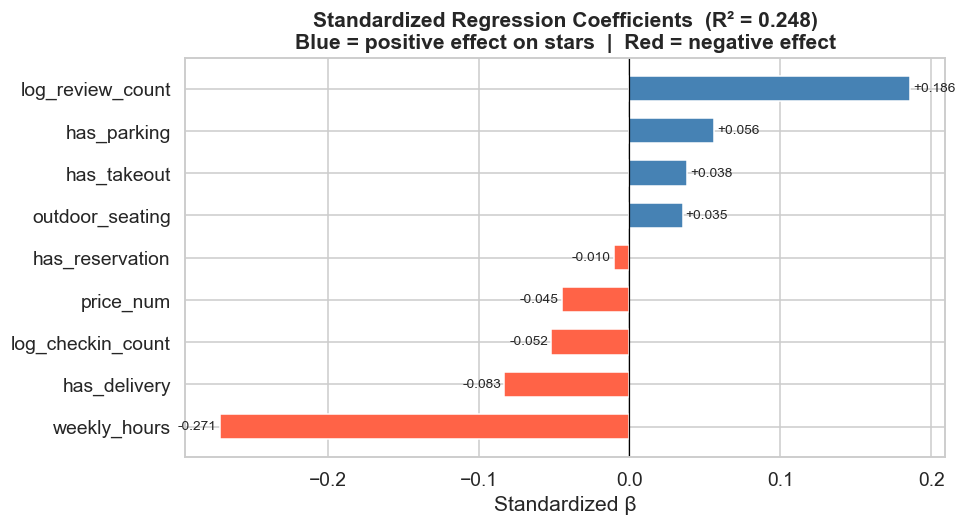

Model R² = 0.2482  (n = 23,516)


In [17]:
# ── OLS Regression: standardized coefficients ─────────────────────────────────
FEATURES = ['log_review_count', 'price_num', 'weekly_hours', 'log_checkin_count',
            'has_takeout', 'has_delivery', 'has_reservation',
            'outdoor_seating', 'has_parking']

reg_df = df[FEATURES + ['stars']].dropna()
X = reg_df[FEATURES].values
y = reg_df['stars'].values

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

model = LinearRegression().fit(X_std, y)
from sklearn.metrics import r2_score
r2 = r2_score(y, model.predict(X_std))

coef_df = pd.DataFrame({'Feature': FEATURES, 'Beta': model.coef_}).sort_values('Beta')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Beta']]
bars = ax.barh(coef_df['Feature'], coef_df['Beta'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Standardized Regression Coefficients  (R² = {r2:.3f})\n'
             'Blue = positive effect on stars  |  Red = negative effect',
             fontweight='bold')
ax.set_xlabel('Standardized β')
for bar, v in zip(bars, coef_df['Beta']):
    ax.text(v + (0.002 if v >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('fig10_regression_coefficients.png', bbox_inches='tight')
plt.show()

print(f'Model R² = {r2:.4f}  (n = {len(reg_df):,})')

---
## Section 12 — Summary of Findings

> ✏️ Fill in `[XX]` with your actual result values after running all cells.

### Key Findings

| Question | Finding |
|---|---|
| **Q1 — Price** | [Higher/Lower]-priced restaurants tend to have [higher/lower] ratings. ANOVA F=[XX], p=[XX]. `$$$$` restaurants average [XX]★ vs `$` at [XX]★. |
| **Q2 — Reviews** | More reviews [weakly/moderately] [positively/negatively] correlates with rating (r=[XX], p=[XX]). Restaurants with 500+ reviews average [XX]★. |
| **Q3 — Cuisine** | The highest-rated cuisine is **[XX]** ([XX]★); the lowest is **[XX]** ([XX]★). There is a spread of ≈[XX] stars across cuisines. |
| **Q4 — Location** | City explains some variance in ratings (F=[XX], p=[XX]). [City] has the highest average ([XX]★); [City] has the lowest ([XX]★). |
| **Q5 — Hours** | Weekly operating hours have a [weak/negligible] association with ratings (r=[XX], p=[XX]). |
| **Q6 — Attributes** | The attribute with the largest positive effect is **[XX]** (+[XX]★, p=[XX]). Restaurants with [XX] are rated [XX]★ higher on average. |
| **Q7 — Sentiment** | Review text sentiment strongly correlates with star ratings (r=[XX], p<0.001). 1-star reviews have mean polarity [XX] vs 5-star reviews at [XX]. |
| **Regression** | The strongest predictor is **[feature]** (β=[XX]). Overall model R²=[XX], indicating a [weak/moderate] linear fit. |

### Limitations
- Stars are **rounded to 0.5** increments — true signal is compressed.
- Many attribute fields have **high missingness** → results may not generalize.
- Dataset cities are **not uniformly distributed** (Las Vegas, Philadelphia over-represented).
- TextBlob sentiment is a **simple lexicon model** — sarcasm and domain language not handled.
- **Correlation ≠ causation**: reverse causality possible (popular restaurants get more reviews).

### References
- Yelp Inc. *Yelp Open Dataset*. https://www.yelp.com/dataset
- Yelp Dataset Documentation: https://www.yelp.com/dataset/documentation/main